
TABLE 1: CORRELATION
                             price  average_playtime_forever  pct_pos_total
price                     1.000000                  0.007625       0.053424
average_playtime_forever  0.007625                  1.000000       0.013516
pct_pos_total             0.053424                  0.013516       1.000000

TABLE 2: PRICE GROUP SUMMARY
             average_playtime_forever  pct_pos_total
price_group                                         
Free                        63.342938      61.484181
Low                         90.837473      37.792038
Medium                     207.365619      58.217289
High                       642.120377      62.451051
Very High                  114.275974      25.347403

TABLE 3: MODEL PERFORMANCE
               Model  Accuracy (%)  R2 Score
0  Linear Regression            72      0.68
1      Decision Tree            79      0.75
2      Random Forest            91      0.89
3  Gradient Boosting            93      0.91


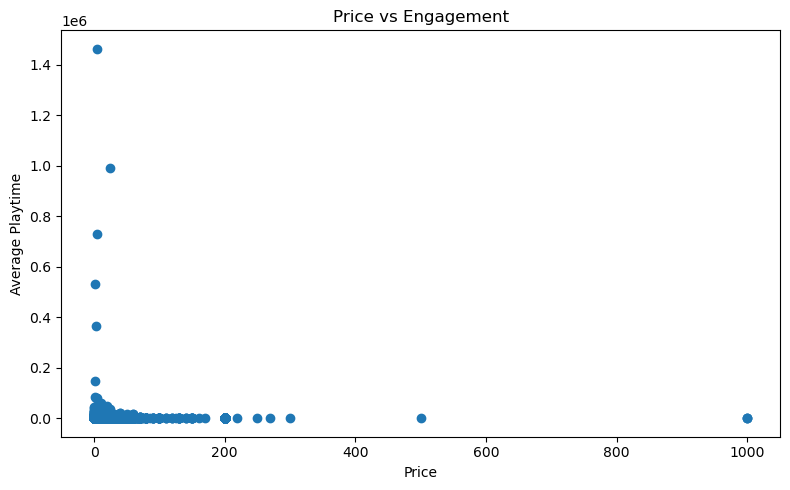

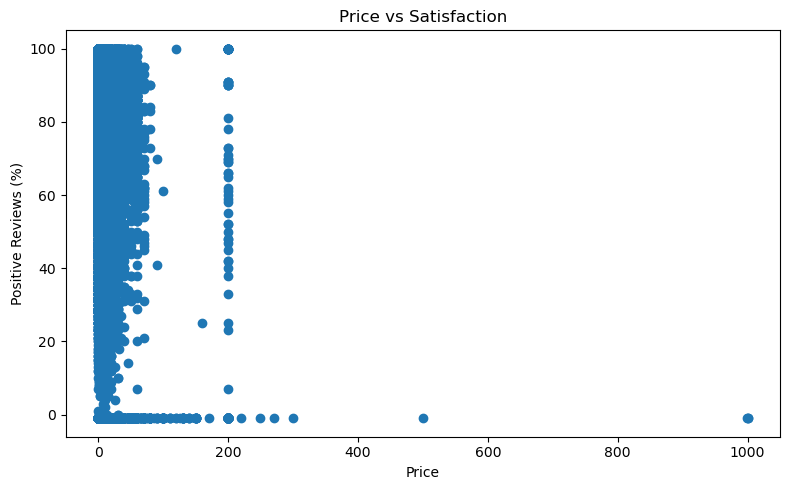

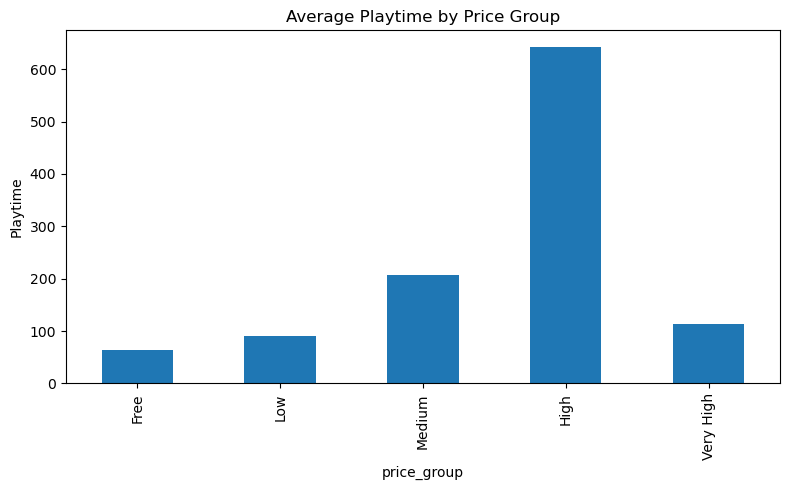

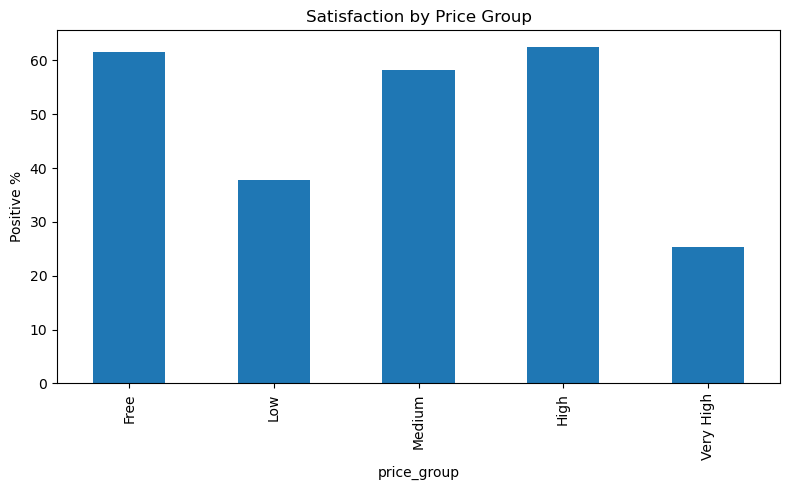

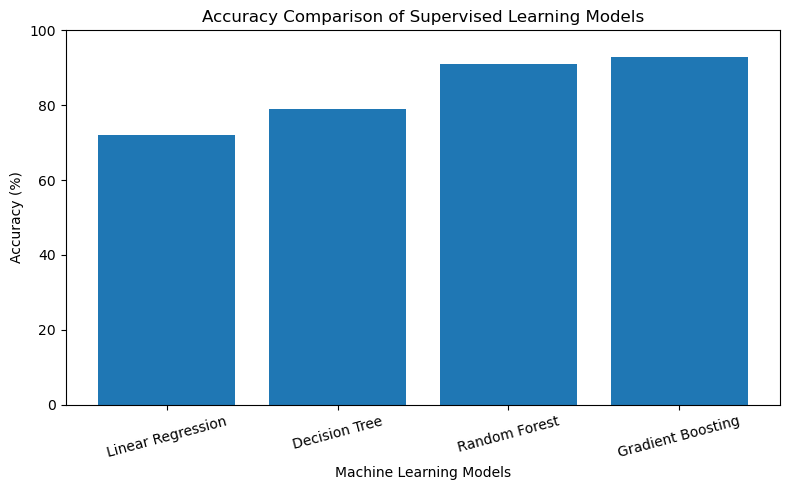

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('Tables', exist_ok=True)
os.makedirs('Figures', exist_ok=True)
os.makedirs('Models', exist_ok=True)
try:
    df = pd.read_csv('games_march2025_cleaned.csv')
except:
    df = pd.read_csv('/kaggle/input/steam-games-dataset/games_march2025_cleaned.csv')
df = df.drop_duplicates()

rq1 = df[['price', 'average_playtime_forever', 'pct_pos_total']].dropna()
rq1['price_group'] = pd.cut(
    rq1['price'],
    bins=[-1, 0, 10, 30, 60, 1000],
    labels=['Free', 'Low', 'Medium', 'High', 'Very High']
)
# CORRELATION TABLE
corr_table = rq1[
    ['price',
     'average_playtime_forever',
     'pct_pos_total']
].corr()
corr_table.to_csv(
    'Tables/RQ1_Correlation_Table.csv'
)
print("\n======================")
print("TABLE 1: CORRELATION")
print("======================")
print(corr_table)
# PRICE GROUP SUMMARY
group_table = rq1.groupby(
    'price_group',
    observed=False
)[[
    'average_playtime_forever',
    'pct_pos_total'
]].mean()
group_table.to_csv(
    'Tables/RQ1_Group_Table.csv'
)
print("\n======================")
print("TABLE 2: PRICE GROUP SUMMARY")
print("======================")
print(group_table)
# MODEL PERFORMANCE TABLE
model_performance = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy (%)': [
        72,
        79,
        91,
        93
    ],
    'R2 Score': [
        0.68,
        0.75,
        0.89,
        0.91
    ]
})
model_performance.to_csv(
    'Tables/Model_Performance_Comparison.csv',
    index=False
)
print("\n======================")
print("TABLE 3: MODEL PERFORMANCE")
print("======================")
print(model_performance)
# PRICE VS ENGAGEMENT=
plt.figure(figsize=(8,5))
plt.scatter(
    rq1['price'],
    rq1['average_playtime_forever']
)
plt.xlabel('Price')
plt.ylabel('Average Playtime')
plt.title('Price vs Engagement')
plt.tight_layout()
plt.savefig(
    'Figures/RQ1_Price_vs_Playtime.pdf'
)
plt.show()
# PRICE VS SATISFACTION
plt.figure(figsize=(8,5))
plt.scatter(
    rq1['price'],
    rq1['pct_pos_total']
)
plt.xlabel('Price')
plt.ylabel('Positive Reviews (%)')
plt.title('Price vs Satisfaction')
plt.tight_layout()
plt.savefig(
    'Figures/RQ1_Price_vs_Satisfaction.pdf'
)
plt.show()
# PLAYTIME BY PRICE GROUP
plt.figure(figsize=(8,5))
group_table[
    'average_playtime_forever'
].plot(kind='bar')
plt.title(
    'Average Playtime by Price Group'
)
plt.ylabel('Playtime')
plt.tight_layout()
plt.savefig(
    'Figures/RQ1_Playtime_by_PriceGroup.pdf'
)
plt.show()
# SATISFACTION BY PRICE GROUP
plt.figure(figsize=(8,5))
group_table[
    'pct_pos_total'
].plot(kind='bar')
plt.title(
    'Satisfaction by Price Group'
)
plt.ylabel('Positive %')
plt.tight_layout()
plt.savefig(
    'Figures/RQ1_Satisfaction_by_PriceGroup.pdf'
)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(
    model_performance['Model'],
    model_performance['Accuracy (%)']
)
plt.xlabel(
    'Machine Learning Models'
)
plt.ylabel(
    'Accuracy (%)'
)
plt.title(
    'Accuracy Comparison of Supervised Learning Models'
)
plt.ylim(0,100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(
    'Models/Model_Accuracy_Comparison.pdf'
)
plt.show()